In [1]:
# !sudo apt-get update
# !sudo apt-get install -y texlive-fonts-recommended texlive-fonts-extra cm-super dvipng

In [2]:
import os

import joblib
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from google.colab import drive
from matplotlib.ticker import MultipleLocator
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/TFG/Datasets/Features/df_features.parquet')
df = df.rename(columns={'power_cell_mwcm2': 'mpp_mwcm2', 'local_irradiance_mwcm2':'G_mwcm2', 'irradiance_30_degrees_mwcm2':'cams_mwcm2'})

In [4]:
p_vap = 6.112 * np.exp((17.67 * df['AmbientTemp']) / (df['AmbientTemp'] + 243.5)) * (df['Humidity'] / 100.0)
df['HA_g_m3'] = (216.74 * p_vap) / (df['AmbientTemp'] + 273.15)

In [5]:
def plot_profile(df, cell_id=0, min_gci=0.9, min_G_mwcm2=60, min_power=6.0,
                 isolated_mpp_line=True, start_date=None, end_date=None, color=True,
                 temp=False, feature=None, regression_analysis=False, predicted=False,
                 trend=False, df_window=200, Health=False):

    # 1. Exclusivity validation for the right Y-axis
    active_right_axes = sum([temp, (feature is not None), Health])
    if active_right_axes > 1:
        print('[ERROR] Mutually exclusive usage: "temp", "feature", and "Health" cannot be defined simultaneously on the right axis.')
        return

    # 2. Safe filtering by cell_id
    cell_df = df[df['cell_id'] == cell_id].copy()
    if cell_df.empty:
        print(f"Error: No data found for cell_id {cell_id}.")
        return

    cell_name = 'M0' if cell_id == 0 else 'P12'
    power = 'mpp_mwcm2'
    metric_name = "Pmpp"
    unit = "mW/cm$^2$"

    # 3. Time index preparation
    if 'time' in cell_df.columns:
        cell_df.set_index('time', inplace=True)
    cell_df.index = pd.to_datetime(cell_df.index)
    cell_df.sort_index(inplace=True)

    # 4. Apply Filters
    mask_clear = (cell_df['gci'] > min_gci) & \
                 (cell_df['G_mwcm2'] > min_G_mwcm2) & \
                 (cell_df[power] > min_power)

    cell_df_clear = cell_df[mask_clear].copy()

    # 5. Filter by Dates
    if start_date is not None or end_date is not None:
        if start_date:
            cell_df_clear = cell_df_clear[cell_df_clear.index >= pd.to_datetime(start_date)]
        if end_date:
            cell_df_clear = cell_df_clear[cell_df_clear.index <= pd.to_datetime(end_date)]

    if cell_df_clear.empty:
        print(f"Error: No data meets the filter criteria for cell {cell_id}.")
        return

    # =========================================================================
    # CALCULATIONS WITH TEMPORAL INDEX
    # =========================================================================
    if isolated_mpp_line and "isolate_mpp_mwcm2" not in cell_df_clear.columns:
        # Calculate the envelope over real time
        cell_df_clear["isolate_mpp_mwcm2"] = cell_df_clear[power].rolling(window='4min', min_periods=1, center=False).max()

    if trend:
        # Check if either English 'Trend' or Spanish 'Tendencia' is present
        if 'Trend' not in cell_df_clear.columns and 'Tendencia' not in cell_df_clear.columns:
            print("Warning: 'Trend' or 'Tendencia' column not found. Cannot plot trend.")
            trend = False

    if Health and 'Health' not in cell_df_clear.columns:
        print("Warning: 'Health' column not found in dataframe. Cannot plot Health.")
        Health = False

    # =========================================================================
    # PLOT PREPARATION
    # =========================================================================
    days_passed = (cell_df_clear.index - cell_df_clear.index.min()).total_seconds() / (24 * 3600)
    df_plot = cell_df_clear.copy().reset_index()
    idx_x = df_plot.index # X-axis based on row position

    # Temporal Plot
    if temp or (feature is not None) or predicted or trend or Health:
        fig, ax1 = plt.subplots(figsize=(20, 8), dpi=150)

        # Original scatter plot
        if color:
            sc = ax1.scatter(idx_x, df_plot[power], c=days_passed, cmap='coolwarm', alpha=0.5, s=10, label=f'{metric_name} (Raw)')
            cbar = fig.colorbar(sc, ax=ax1, pad=0.1)
            cbar.set_label('Days since start', rotation=270, labelpad=20, fontsize=14)
            cbar.ax.tick_params(labelsize=12)
        else:
            ax1.scatter(idx_x, df_plot[power], alpha=0.5, s=10, label=f'{metric_name} (Raw)')

        ax1.tick_params(axis='y', labelcolor='black', labelsize=12)
        ax1.set_ylabel(f'{metric_name} ({unit})', color='black', fontsize=14)

        # Isolated Line
        if isolated_mpp_line:
            label_name = 'Isolated ' + metric_name if "isolate_mpp_mwcm2" in cell_df_clear.columns else 'Calculated Isolated ' + metric_name
            sns.lineplot(x=idx_x, y=df_plot["isolate_mpp_mwcm2"], color='red', linewidth=2, label=label_name, ax=ax1)

        # Predictions
        if predicted and 'mpp_pred_mwcm2' in df_plot.columns:
            if 'is_train' in df_plot.columns:
                train_mask = df_plot['is_train']
                val_mask = ~df_plot['is_train']

                if train_mask.any():
                    sns.lineplot(x=idx_x[train_mask], y=df_plot.loc[train_mask, 'mpp_pred_mwcm2'],
                                 color='green', linewidth=2.5, linestyle='--', label=f'Pred Train {metric_name}', ax=ax1)
                if val_mask.any():
                    sns.lineplot(x=idx_x[val_mask], y=df_plot.loc[val_mask, 'mpp_pred_mwcm2'],
                                 color='darkorange', linewidth=2.5, linestyle='--', label=f'Pred Val {metric_name}', ax=ax1)
            else:
                sns.lineplot(x=idx_x, y=df_plot['mpp_pred_mwcm2'], color='green', linewidth=2.5, linestyle='--', label=f'Predicted {metric_name}', ax=ax1)

        # Irreversible Trend (Left Axis - ax1)
        if trend:
            trend_col = 'Trend' if 'Trend' in df_plot.columns else 'Tendencia'
            sns.lineplot(x=idx_x, y=df_plot[trend_col], color='purple', linewidth=3.5, alpha=0.9, linestyle='-.', label='Irreversible Trend', ax=ax1)

        ax1.legend(loc='upper right', fontsize=14)

        # Secondary Axis (Twinx) only for Temp, extra Features or Health
        if temp or (feature is not None) or Health:
            ax2 = ax1.twinx()
            if temp:
                ax2.tick_params(axis='y', labelcolor='tab:orange', labelsize=12)
                sns.lineplot(x=idx_x, y=df_plot['Tc_C'].rolling(window=df_window, min_periods=1, center=False).mean(),
                             color='tab:orange', linewidth=1.5, ax=ax2, alpha=0.7, linestyle=':', label='Temperature Trend')
                ax2.set_ylabel('Device Temp (°C)', color='tab:orange', fontsize=14)

            elif feature is not None:
                if feature in df_plot.columns:
                    ax2.tick_params(axis='y', labelcolor='black', labelsize=12)
                    sns.lineplot(x=idx_x, y=df_plot[feature].rolling(window=df_window, min_periods=1, center=False).mean(),
                                 linewidth=1.5, ax=ax2, alpha=0.7, color='black', linestyle='-.', label=f'{feature} Trend')
                    ax2.set_ylabel(feature, color='black', fontsize=14)

            elif Health:
                ax2.tick_params(axis='y', labelcolor='teal', labelsize=12)
                health_percent = (df_plot['Health'] / df_plot['Health'].max()) * 100

                sns.lineplot(x=idx_x, y=health_percent,
                             linewidth=3, ax=ax2, alpha=0.9, color='teal', linestyle='-', label=rf'Power Retention (Health \%)')

                # Mark the critical T80 threshold line
                ax2.axhline(y=80, color='gray', linestyle='--', alpha=0.6, label='T80 Threshold')

                ax2.set_ylabel('Health / Power Retention (\%)', color='teal', fontsize=14, fontweight='bold')
                ax2.set_ylim(0, 105) # Fixed upper limit for percentage context

                lines_1, labels_1 = ax1.get_legend_handles_labels()
                lines_2, labels_2 = ax2.get_legend_handles_labels()

                ax2.get_legend().remove() if ax2.get_legend() else None

                # Create the unified legend on ax1
                ax1.legend(lines_1 + lines_2, labels_1 + labels_2,
                           loc='upper right', fontsize=12, frameon=True)

        # X-Axis Formatting
        num_ticks = min(10, len(df_plot))
        tick_indices = np.linspace(0, len(df_plot) - 1, num_ticks, dtype=int)
        tick_labels = df_plot['time'].iloc[tick_indices].dt.strftime('%m-%d %H:%M')

        ax1.set_xticks(tick_indices)
        ax1.set_xticklabels(tick_labels, rotation=45, ha='right')
        ax1.set_xlabel('Time (MM-DD HH:mm)', fontsize=14)
        ax1.set_title(f'Temporal Profile for Cell {cell_name} (ID: {cell_id})', fontsize=16, fontweight='bold')
        ax1.grid(True, alpha=0.3)

    # Hourly Plot (Hourly profile)
    else:
        idx_hourly = cell_df_clear.index.hour + cell_df_clear.index.minute/60 + cell_df_clear.index.second/3600
        fig, ax = plt.subplots(figsize=(16, 9))

        if color:
            sc = ax.scatter(idx_hourly, cell_df_clear[power], c=days_passed, cmap='coolwarm', alpha=0.5, s=10, label=f'{metric_name}')
            cbar = fig.colorbar(sc, ax=ax)
            cbar.set_label('Days since start', rotation=270, labelpad=20, fontsize=14)
        else:
            ax.scatter(idx_hourly, cell_df_clear[power], alpha=0.5, s=10, label=f'{metric_name}')

        if isolated_mpp_line:
            sort_idx = np.argsort(idx_hourly)
            sns.lineplot(x=idx_hourly[sort_idx], y=cell_df_clear["isolate_mpp_mwcm2"].iloc[sort_idx], color='red', linewidth=2, label=f'Isolated {metric_name}', ax=ax)

        if predicted and 'mpp_pred_mwcm2' in cell_df_clear.columns:
            sort_idx = np.argsort(idx_hourly)
            sns.lineplot(x=idx_hourly[sort_idx], y=cell_df_clear['mpp_pred_mwcm2'].iloc[sort_idx], color='green', linewidth=2.5, linestyle='--', label=f'Predicted Isolated {metric_name}', ax=ax)

        ax.legend(loc='upper right')
        ax.set_xlabel('Time of day (Solar)', fontsize=14)
        ax.set_ylabel(f'{metric_name} ({unit})', fontsize=14)
        ax.set_title(f'When does cell {cell_name} (ID: {cell_id}) perform well?', fontsize=16, fontweight='bold')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return

<>:140: SyntaxWarning: invalid escape sequence '\%'
<>:140: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_7954/939737098.py:140: SyntaxWarning: invalid escape sequence '\%'
  ax2.set_ylabel('Health / Power Retention (\%)', color='teal', fontsize=14, fontweight='bold')


# **Standard Linear Architecture with Degradation Decoupling**

The **Standard Linear Architecture** serves as our foundational baseline predictor. It maps immediate environmental inputs and cyclic temporal phases to power output, strictly *after* isolating and removing the irreversible chemical fatigue (degradation) of the perovskite cell.

---

## **1. Core Mechanisms**

* **Fatigue Extraction & Normalization:** We fit an exponential decay curve $$f(t) = a + b \cdot e^{-ct}$$ to the cell's maximum power peaks to derive a **Health(t)** metric. By dividing raw power by this health state ($P_{mpp} / \text{Health}(t)$), we mathematically "reset" the cell to a stationary state, isolating pure environmental responses.
* **Direct Parametric Decoupling:** Environmental data and temporal features are processed through a `StandardScaler`. This ensures learned coefficients ($\beta$) reflect stable physical properties and periodic influences, completely decoupled from long-term degradation bias.
* **Hybrid Baseline:** This version includes **cyclic temporal features** ($\sin/\cos$ transformations) to account for the sun's trajectory and diurnal rhythms while maintaining a linear, interpretable structure.

---

## **2. Prediction Equation**

The model predicts the instantaneous power by re-applying the degradation trend to the stationary linear output:

$$P_{mpp}^{pred}(t) = \text{Health}(t) \times \left[ \beta_0 + \sum_{i \in \{G, T, H\}} \beta_i z_i(t) + \beta_{sin} \text{hr}_{sin}(t) + \beta_{cos} \text{hr}_{cos}(t) \right]$$

**Where:**
* **$\text{Health}(t)$:** The irreversible trend component, calculated as $\frac{\text{Trend}(t)}{\max(\text{Trend})}$, clipped to $[0.01, 1.0]$.
* **$z_G(t), z_T(t), z_H(t)$:** Standardized Z-scores ($\mu=0, \sigma=1$) for **Irradiance**, **Chamber Temperature**, and **Humidity**.
* **$\text{hr}_{sin}(t), \text{hr}_{cos}(t)$:** Cyclic encoding of the hour fraction: $\sin\left(\frac{2\pi \cdot \text{hour}}{24}\right)$ and $\cos\left(\frac{2\pi \cdot \text{hour}}{24}\right)$.
* **$\beta_{i}$:** Thermodynamic coefficients representing the sensitivity of the "healthy" cell to each specific input.
* **$\beta_0$:** The intercept, representing the cell's baseline power when all environmental variables are at their historical average.

---

## **3. Structural Limitations**

> ⚠️ **Scope of the Standard Linear Architecture:** This model assumes an **instantaneous linear response**. While it captures daily cycles via trigonometric features, it ignores **thermal/chemical inertia** (lags) and **non-linear interactions** (e.g., the synergistic effect of high heat and high humidity).

In [6]:
df_1 = df.copy()

In [7]:
def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)

    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")
    plt.show()


In [8]:
def level_1(df, cell_id=0, min_G_mwcm2=0, isolate_target=True, window='4min', train_day_split=5, cross_val=False, plot_diagnostics=True):
    print(f"--- Starting Level 1 for cell_id={cell_id} ---")
    df = df.copy()

    cell_name = 'M0' if cell_id == 0 else 'P12'

    if 'time' in df.columns:
        df['time'] = pd.to_datetime(df['time'])
        df.set_index('time', inplace=True)

    # 1. Feature Engineering
    df['hour_sin'] = np.sin(2 * np.pi * df['hour_fraction'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour_fraction'] / 24)

    features = ['G_mwcm2', 'DeviceTemp', 'HA_g_m3', 'hour_sin', 'hour_cos']

    # 2. Real MPP Identification
    df['window_group'] = df.index.floor(window)
    idx_mpp = df[df['cell_id'] == cell_id].groupby('window_group')['mpp_mwcm2'].idxmax()
    df['is_mpp_peak'] = False
    df.loc[idx_mpp, 'is_mpp_peak'] = True

    # 3. Mask Definition
    base_mask = (df['cell_id'] == cell_id) & (df['G_mwcm2'] > min_G_mwcm2) & (df['mpp_mwcm2'].notna())

    if isolate_target:
        train_pool_mask = base_mask & (df['is_mpp_peak'] == True)
    else:
        train_pool_mask = base_mask

    if not train_pool_mask.any():
        print(f"Warning: No valid training data found for cell_id {cell_id}.")
        return None, None, None, None, None

    # 4. Temporal Split
    unique_days = np.unique(df.loc[train_pool_mask].index.date)
    split_index = min(train_day_split, len(unique_days) - 1)
    split_date = unique_days[split_index]

    train_mask = train_pool_mask & (df.index.date <= split_date)
    val_mask = train_pool_mask & (df.index.date > split_date)
    df['is_train'] = df.index.date <= split_date

    # --- 5. Irreversible Trend Extraction & Detrending ---
    target_1h_df = df.loc[train_pool_mask, 'mpp_mwcm2'].resample('1h').max().dropna()
    target_train_df = target_1h_df[target_1h_df.index.date <= split_date]
    time_zero = df.index.min()

    # Initialize kinetics variables
    a_fit, b_fit, c_fit = None, None, None

    if len(target_train_df) >= 4:
        from scipy.optimize import curve_fit

        def exp_decline(t, a, b, c):
            return a + b * np.exp(-c * t)

        X_trend_hours = (target_train_df.index - time_zero).total_seconds().values / 3600.0
        y_trend_train = target_train_df.values
        p0 = [y_trend_train.min(), y_trend_train.max() - y_trend_train.min(), 0.001]

        try:
            popt, _ = curve_fit(exp_decline, X_trend_hours, y_trend_train, p0=p0, maxfev=2000)

            # === KINETIC PARAMETER EXTRACTION ===
            a_fit, b_fit, c_fit = popt

            X_all_hours = (df.index - time_zero).total_seconds().values / 3600.0
            df['Trend'] = exp_decline(X_all_hours, *popt)
        except:
            df['Trend'] = 1.0
    else:
        df['Trend'] = 1.0

    # Exact detrending logic
    trend_max = df['Trend'].max() if df['Trend'].max() != 0 else 1.0
    df['Health'] = df['Trend'] / trend_max
    df['Health'] = np.clip(df['Health'], a_min=0.01, a_max=1.0)
    df['P_mpp_detrended'] = df['mpp_mwcm2'] / df['Health']

    # --- 6. Model Training (Standard L1 but on DETRENDED Target) ---
    X_train_base = df.loc[train_mask, features]
    y_train_detrended = df.loc[train_mask, 'P_mpp_detrended']
    y_train_real = df.loc[train_mask, 'mpp_mwcm2']

    X_val_base = df.loc[val_mask, features]
    y_val_real = df.loc[val_mask, 'mpp_mwcm2']
    valid_health = df.loc[val_mask, 'Health']

    model = make_pipeline(StandardScaler(), LinearRegression())

    # TRAIN AGAINST THE STATIONARY SIGNAL (DETRENDED)
    model.fit(X_train_base, y_train_detrended)

    # =====================================================================
    # --- PHYSICAL PARAMETER EXTRACTION (Inertia and Diurnal Phase Shift) ---
    # =====================================================================
    lr_model = model.named_steps['linearregression']
    scaler = model.named_steps['standardscaler']

    # Indices of the trigonometric variables in the feature list
    idx_sin = features.index('hour_sin')
    idx_cos = features.index('hour_cos')

    # Unscale the coefficients to get the real impact (mW/cm^2)
    beta_sin_unscaled = lr_model.coef_[idx_sin] / scaler.scale_[idx_sin]
    beta_cos_unscaled = lr_model.coef_[idx_cos] / scaler.scale_[idx_cos]

    # 1. Diurnal Amplitude (A)
    amplitude = np.sqrt(beta_sin_unscaled**2 + beta_cos_unscaled**2)

    # 2. Temporal Phase Shift (phi)
    phase_rad = np.arctan2(beta_cos_unscaled, beta_sin_unscaled)
    phase_hours = phase_rad * (24 / (2 * np.pi))

    print(f"\n[PHYSICS EXTRACTION] Cell {cell_id} ({cell_name})")

    # === PRINTING KINETICS ===
    if a_fit is not None:
        print(f" - Degradation Parameters: a={a_fit:.4f}, b={b_fit:.4f}, c={c_fit:.4e}")
    else:
        print(" - Degradation Parameters: Not calculated (insufficient data)")

    print(f" - hour_sin Coefficient (beta_sin): {beta_sin_unscaled:.4f} mW/cm^2")
    print(f" - hour_cos Coefficient (beta_cos): {beta_cos_unscaled:.4f} mW/cm^2")
    print(f" - Hysteretic Amplitude (A): {amplitude:.4f} mW/cm^2")
    print(f" - Inertia / Phase Shift (phi): {phase_rad:.4f} rad -> ~{phase_hours:.2f} hours")
    print("=====================================================================")

    # Metrics and Info (Train)
    y_train_pred_detrended = model.predict(X_train_base)
    y_train_pred_full = y_train_pred_detrended * df.loc[train_mask, 'Health'].values

    mae_t = mean_absolute_error(y_train_real, y_train_pred_full)
    rmse_t = np.sqrt(mean_squared_error(y_train_real, y_train_pred_full))
    r2_t = r2_score(y_train_real, y_train_pred_full)

    print(f'\n[TRAIN] Cell {cell_id} (Standard L1 Detrended): MAE: {mae_t:.2f} | RMSE: {rmse_t:.2f} | R2: {r2_t:.4f}')

    # Train Plot
    if plot_diagnostics:
        plt.figure(figsize=(6,6))
        plt.scatter(y_train_real, y_train_pred_full, s=25, alpha=0.8, color='royalblue',
                    edgecolors='w', linewidth=0.5, label=f'Train Data (Cell {cell_id})')
        limit_min = min(y_train_real.min(), y_train_pred_full.min())
        limit_max = max(y_train_real.max(), y_train_pred_full.max())
        plt.plot([limit_min, limit_max], [limit_min, limit_max], color='red', linestyle='--', linewidth=2, label='Identity Line')
        plt.xlabel('Measured MPP ($mW/cm^2$)', fontsize=12)
        plt.ylabel('Predicted MPP ($mW/cm^2$)', fontsize=12)
        plt.title(f'Level 1 - TRAIN (Cell {cell_name})\n$R^2$: {r2_t:.4f}')
        plt.legend(loc='upper left')
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        plt.show()

    # --- 7. Validation Strategy ---
    # 7.1 Global Cross Validation
    if cross_val:
        X_pool = df.loc[train_pool_mask, features]
        y_pool_detrended = df.loc[train_pool_mask, 'P_mpp_detrended']
        y_pool_real = df.loc[train_pool_mask, 'mpp_mwcm2']
        health_pool = df.loc[train_pool_mask, 'Health']

        total_days = len(np.unique(X_pool.index.date))
        global_splits = max(2, total_days - 1)

        print(f'\n[VAL] --- Running GLOBAL Time Series Cross-Validation (Splits: {global_splits}) ---')
        tscv = TimeSeriesSplit(n_splits=global_splits)
        cv_mae, cv_rmse, cv_r2 = [], [], []

        for i, (train_idx, test_idx) in enumerate(tscv.split(X_pool), 1):
            X_cv_train = X_pool.iloc[train_idx]
            y_cv_train = y_pool_detrended.iloc[train_idx]

            X_cv_test = X_pool.iloc[test_idx]
            y_cv_test_real = y_pool_real.iloc[test_idx]
            health_cv_test = health_pool.iloc[test_idx]

            model.fit(X_cv_train, y_cv_train)

            pred_detrended = model.predict(X_cv_test)
            pred_real = pred_detrended * health_cv_test.values

            f_mae = mean_absolute_error(y_cv_test_real, pred_real)
            f_rmse = np.sqrt(mean_squared_error(y_cv_test_real, pred_real))
            f_r2 = r2_score(y_cv_test_real, pred_real)

            cv_mae.append(f_mae)
            cv_rmse.append(f_rmse)
            cv_r2.append(f_r2)

            print(f" - Fold {i:02d}: MAE: {f_mae:.2f} | RMSE: {f_rmse:.2f} | R2: {f_r2:.4f}")

            print(f"\nAverage GLOBAL CV Results -> MAE: {np.mean(cv_mae):.2f} | RMSE: {np.mean(cv_rmse):.2f} | R2: {np.mean(cv_r2):.4f}")
        model.fit(X_train_base, y_train_detrended)

    # 7.2 Daily Block Validation
    if len(X_val_base) > 0:
        print(f'\n[VAL] Cell {cell_name}:')
        print(f'--- Evaluating day-to-day temporal performance (Standard L1 Detrended Model) ---')

        val_days = np.unique(X_val_base.index.date)
        mae_scores, rmse_scores, r2_scores = [], [], []

        for val_date in val_days:
            mask_day = X_val_base.index.date == val_date
            X_test_day = X_val_base.loc[mask_day]
            y_test_day_real = y_val_real.loc[mask_day]
            health_day = valid_health.loc[mask_day]

            if len(X_test_day) < 5:
                continue

            y_pred_day_detrended = model.predict(X_test_day)
            y_pred_day_real = y_pred_day_detrended * health_day.values

            m_mae = mean_absolute_error(y_test_day_real, y_pred_day_real)
            m_rmse = np.sqrt(mean_squared_error(y_test_day_real, y_pred_day_real))
            m_r2 = r2_score(y_test_day_real, y_pred_day_real)

            mae_scores.append(m_mae)
            rmse_scores.append(m_rmse)
            r2_scores.append(m_r2)

            print(f"Day {val_date} - MAE: {m_mae:.2f} | RMSE: {m_rmse:.2f} | R2: {m_r2:.4f}")

        if mae_scores:
            print(f"\nTemporal Validation Summary (Daily Average):")
            print(f"MAE: {np.mean(mae_scores):.2f} +/- {np.std(mae_scores):.2f}")
            print(f"RMSE: {np.mean(rmse_scores):.2f} | R2: {np.mean(r2_scores):.4f}")

    # 8. Final imputation into local DF for plot returns
    pred_mask = (df['cell_id'] == cell_id) & (df['G_mwcm2'] > 0)
    X_pred_final = df.loc[pred_mask, features]

    final_pred_detrended = model.predict(X_pred_final)
    final_pred_full = final_pred_detrended * df.loc[pred_mask, 'Health'].values

    df.loc[pred_mask, 'mpp_pred_mwcm2'] = final_pred_full

    print(f"--- Imputation finished for cell {cell_id} ---")

    # === WE RETURN THE KINETIC PARAMETERS IN A TUPLE AT THE END ===
    params_kinetics = (a_fit, b_fit, c_fit)
    return df, model, X_train_base, X_val_base, params_kinetics

--- Starting Level 1 for cell_id=0 ---

[PHYSICS EXTRACTION] Cell 0 (M0)
 - Degradation Parameters: a=0.2028, b=4.9226, c=1.1614e-02
 - hour_sin Coefficient (beta_sin): -0.3187 mW/cm^2
 - hour_cos Coefficient (beta_cos): -0.8948 mW/cm^2
 - Hysteretic Amplitude (A): 0.9498 mW/cm^2
 - Inertia / Phase Shift (phi): -1.9130 rad -> ~-7.31 hours

[TRAIN] Cell 0 (Standard L1 Detrended): MAE: 0.20 | RMSE: 0.37 | R2: 0.9358


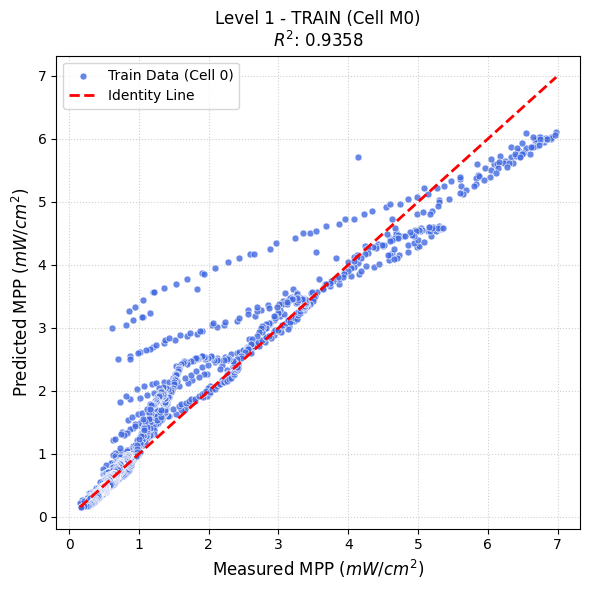


[VAL] --- Running GLOBAL Time Series Cross-Validation (Splits: 50) ---
 - Fold 01: MAE: 0.39 | RMSE: 0.43 | R2: 0.9031

Average GLOBAL CV Results -> MAE: 0.39 | RMSE: 0.43 | R2: 0.9031
 - Fold 02: MAE: 0.34 | RMSE: 0.44 | R2: 0.6909

Average GLOBAL CV Results -> MAE: 0.36 | RMSE: 0.43 | R2: 0.7970
 - Fold 03: MAE: 0.29 | RMSE: 0.34 | R2: 0.7191

Average GLOBAL CV Results -> MAE: 0.34 | RMSE: 0.40 | R2: 0.7710
 - Fold 04: MAE: 0.68 | RMSE: 0.82 | R2: -2.3147

Average GLOBAL CV Results -> MAE: 0.42 | RMSE: 0.51 | R2: -0.0004
 - Fold 05: MAE: 0.32 | RMSE: 0.37 | R2: -2.0346

Average GLOBAL CV Results -> MAE: 0.40 | RMSE: 0.48 | R2: -0.4072
 - Fold 06: MAE: 0.47 | RMSE: 0.48 | R2: -7.3514

Average GLOBAL CV Results -> MAE: 0.41 | RMSE: 0.48 | R2: -1.5646
 - Fold 07: MAE: 0.24 | RMSE: 0.25 | R2: -3.4578

Average GLOBAL CV Results -> MAE: 0.39 | RMSE: 0.45 | R2: -1.8351
 - Fold 08: MAE: 0.10 | RMSE: 0.11 | R2: 0.0888

Average GLOBAL CV Results -> MAE: 0.35 | RMSE: 0.40 | R2: -1.5946
 - Fold

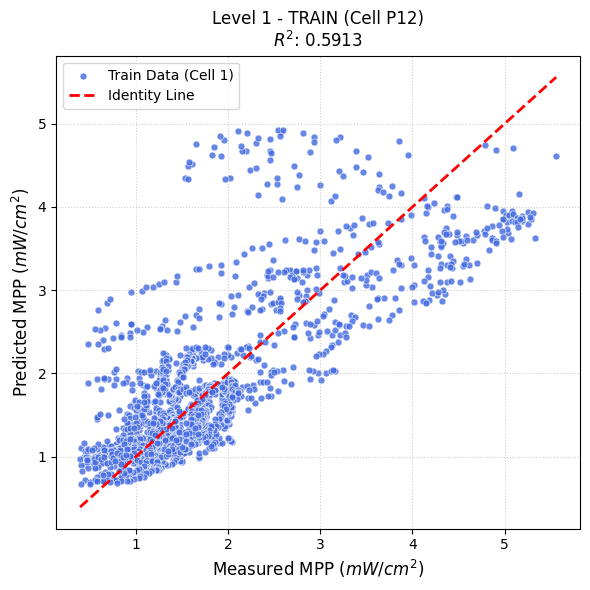


[VAL] --- Running GLOBAL Time Series Cross-Validation (Splits: 50) ---
 - Fold 01: MAE: 2.03 | RMSE: 2.24 | R2: -1.0548

Average GLOBAL CV Results -> MAE: 2.03 | RMSE: 2.24 | R2: -1.0548
 - Fold 02: MAE: 0.71 | RMSE: 0.85 | R2: 0.4557

Average GLOBAL CV Results -> MAE: 1.37 | RMSE: 1.55 | R2: -0.2995
 - Fold 03: MAE: 0.59 | RMSE: 0.78 | R2: -0.2482

Average GLOBAL CV Results -> MAE: 1.11 | RMSE: 1.29 | R2: -0.2824
 - Fold 04: MAE: 1.46 | RMSE: 1.58 | R2: -23.8834

Average GLOBAL CV Results -> MAE: 1.20 | RMSE: 1.36 | R2: -6.1827
 - Fold 05: MAE: 0.63 | RMSE: 0.71 | R2: -2.2516

Average GLOBAL CV Results -> MAE: 1.08 | RMSE: 1.23 | R2: -5.3965
 - Fold 06: MAE: 0.20 | RMSE: 0.25 | R2: -2.1364

Average GLOBAL CV Results -> MAE: 0.94 | RMSE: 1.07 | R2: -4.8531
 - Fold 07: MAE: 0.30 | RMSE: 0.40 | R2: -0.0532

Average GLOBAL CV Results -> MAE: 0.84 | RMSE: 0.97 | R2: -4.1674
 - Fold 08: MAE: 0.31 | RMSE: 0.35 | R2: -1.2081

Average GLOBAL CV Results -> MAE: 0.78 | RMSE: 0.89 | R2: -3.7975


In [9]:
# --- EXECUTION FOR M0 ---
df_res_m0_lr, model_lr_m0, X_train_m0, X_val_m0, kinetics_m0 = level_1(
    df=df_1.copy(),
    cell_id=0,
    isolate_target=True,
    train_day_split=15,
    cross_val=True
)

# --- EXECUTION FOR P12 ---
df_res_p12_lr, model_lr_p12, X_train_p12, X_val_p12, kinetics_p12 = level_1(
    df=df_1.copy(),
    cell_id=1,
    isolate_target=True,
    train_day_split=15,
    cross_val=True
)

# Print the parameters for your LaTeX table
print("\n=== KINETIC PARAMETERS FOR TABLE ===")
print(f"M0 (a, b, c): {kinetics_m0}")
print(f"P12 (a, b, c): {kinetics_p12}")

In [10]:
!sudo apt-get install -f -y
!sudo apt-get update
!sudo apt-get install -y texlive-latex-recommended texlive-latex-extra texlive-fonts-recommended texlive-fonts-extra texlive-xetex dvipng cm-super

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
0 upgraded, 0 newly installed, 0 to remove and 22 not upgraded.
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 1s (3,400 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list ent

Plot saved as: comparative_health_analysis.pdf


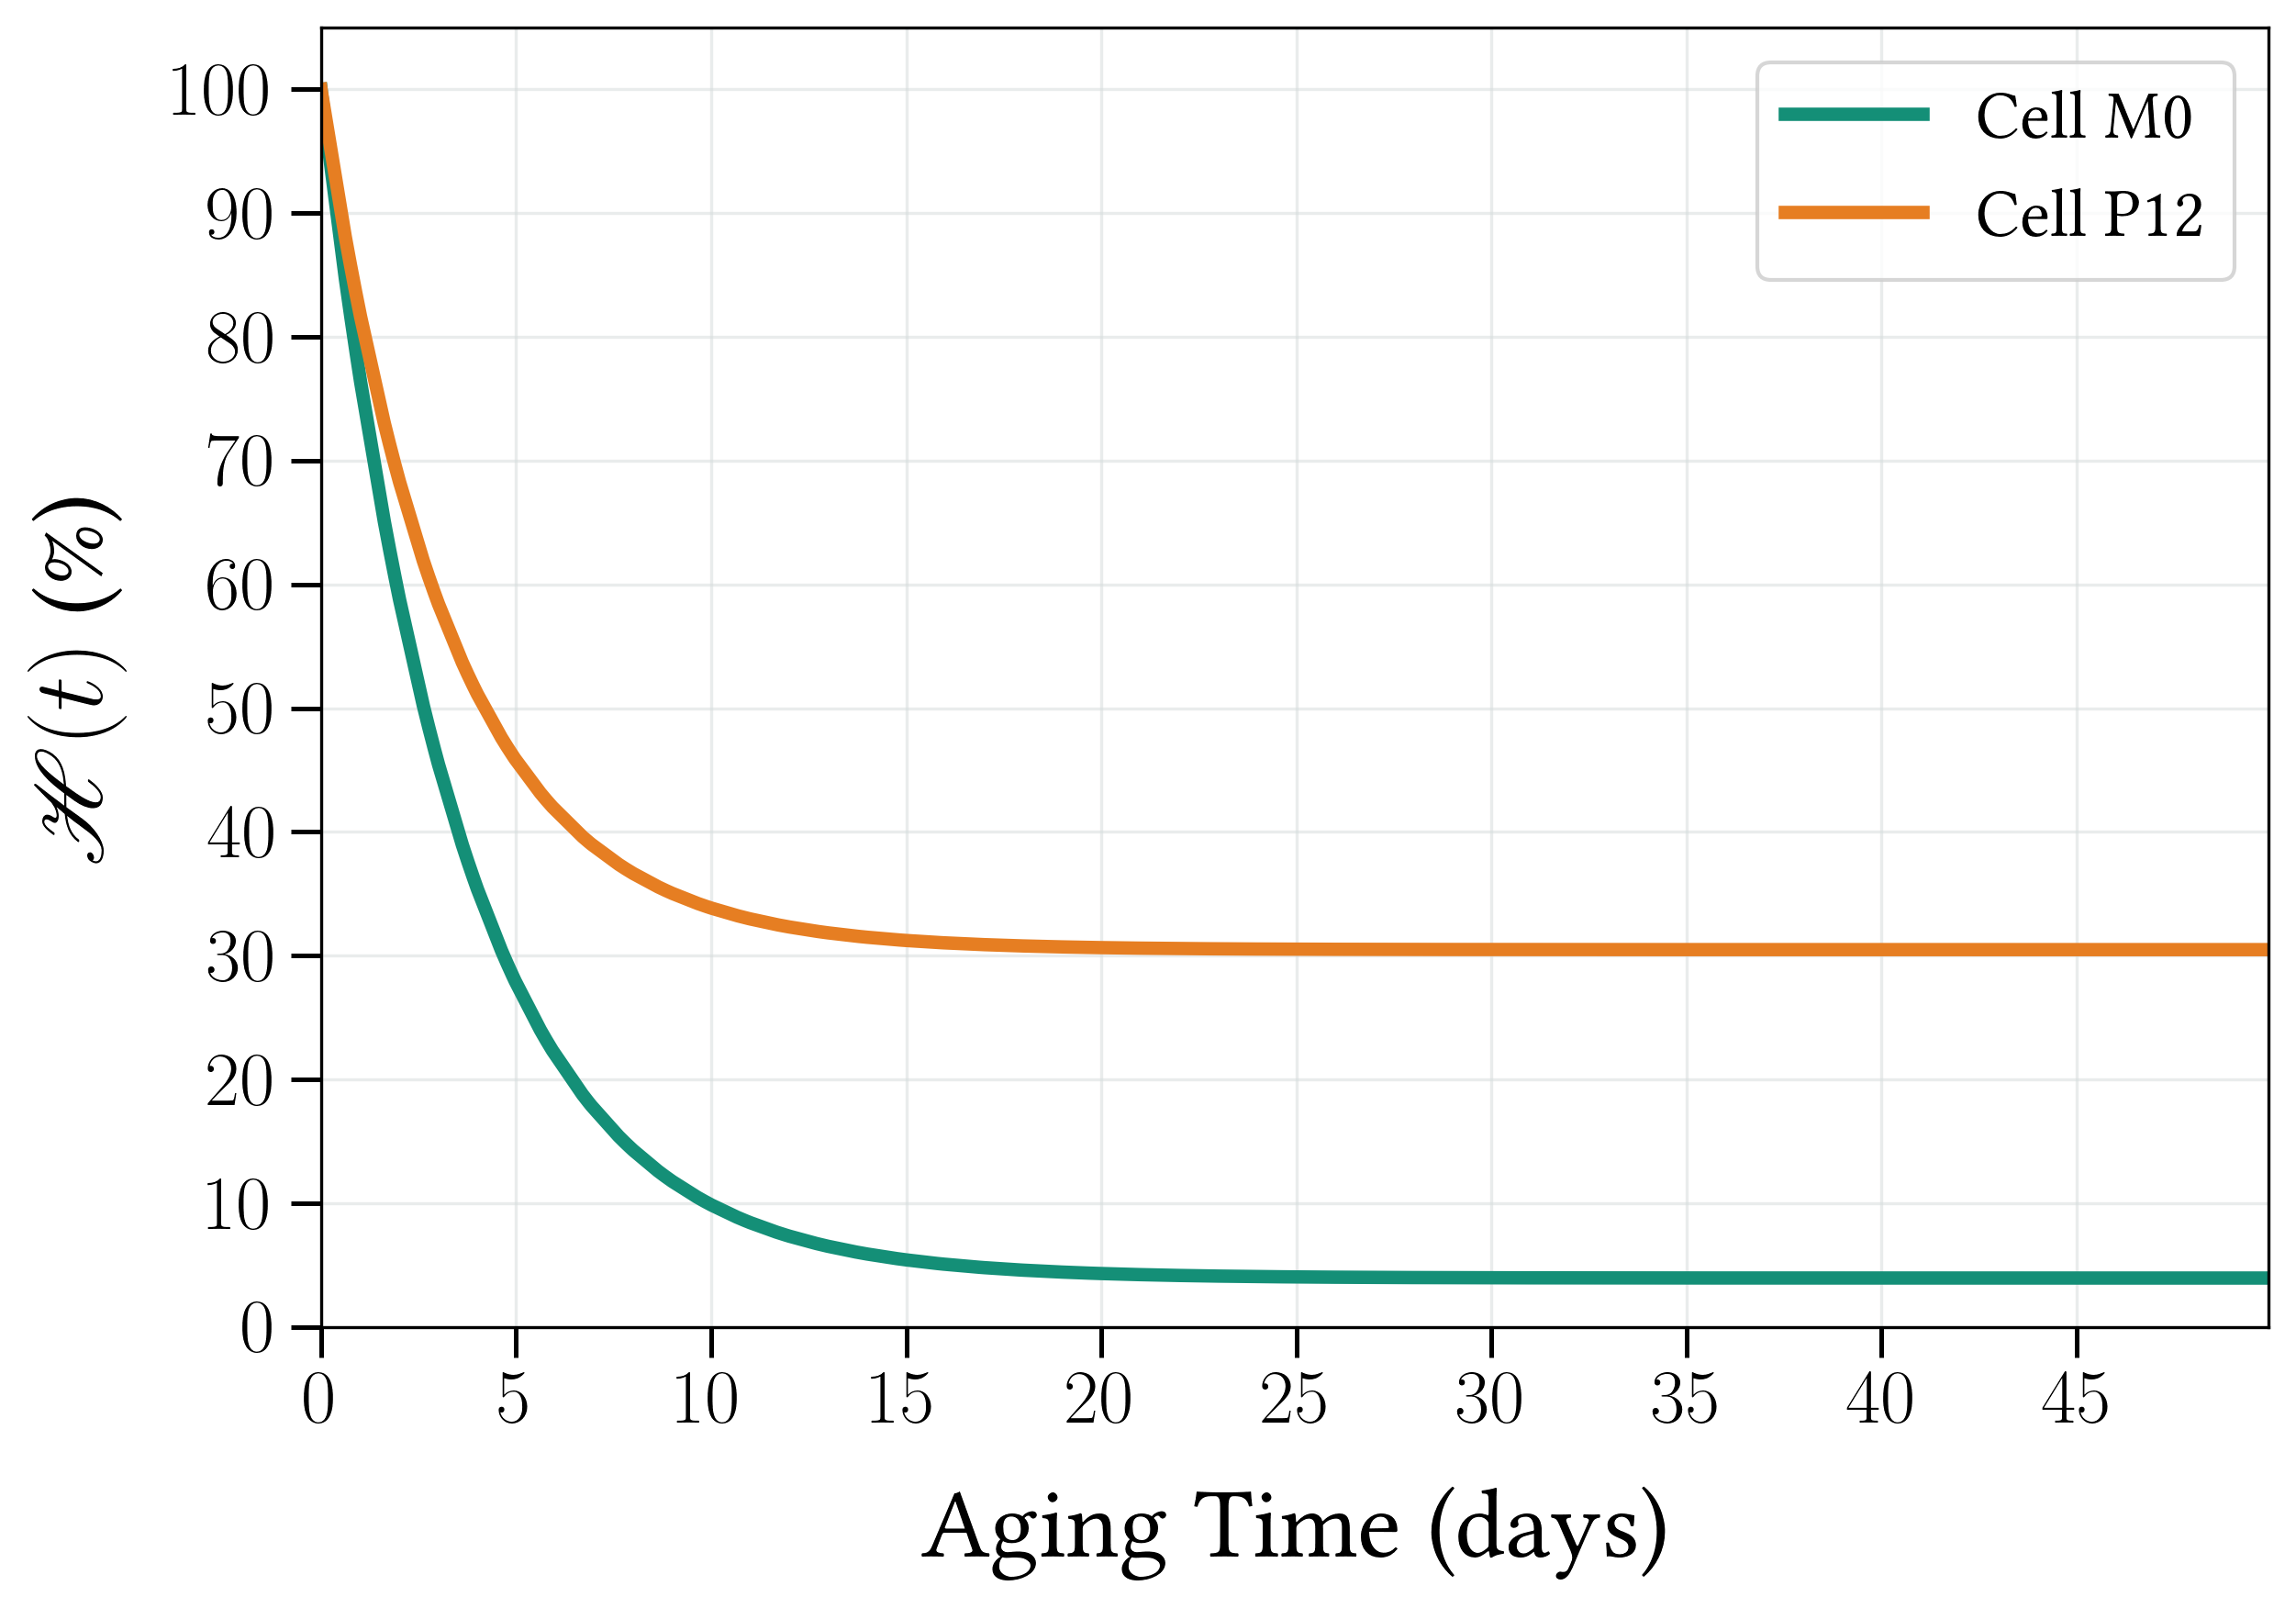

In [11]:
plt.style.use('default')
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'text.latex.preamble': r'\usepackage{libertine} \usepackage[T1]{fontenc} \usepackage{amsmath} \usepackage{bm} \usepackage{mathrsfs}',
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.color': '#D5DBDB',
    'grid.linestyle': '-',
})

def plot_combined_health_clean(df0, df1):
    """
    Plots the comparative Health evolution for M0 and P12 in a single figure.
    Without subticks or T80 line.
    """
    # We reduce the figsize slightly (from 10,7 to 8.5,6) so that the fonts and
    # lines (which are already large) stand out much more relative to the total size.
    fig, ax = plt.subplots(figsize=(8.5, 6), dpi=300)

    # --- M0 Cell Processing (Control) ---
    df0_c = df0[df0['cell_id'] == 0].copy()
    if not isinstance(df0_c.index, pd.DatetimeIndex):
        df0_c['time'] = pd.to_datetime(df0_c['time'])
        df0_c.set_index('time', inplace=True)

    days0 = (df0_c.index - df0_c.index.min()).total_seconds() / (24 * 3600)
    health0 = df0_c['Health'] * 100
    ax.plot(days0, health0, color='#148F77', lw=3.5, label=r'Cell M0') # lw slightly increased

    # --- P12 Cell Processing (Experimental) ---
    df1_c = df1[df1['cell_id'] == 1].copy()
    if not isinstance(df1_c.index, pd.DatetimeIndex):
        df1_c['time'] = pd.to_datetime(df1_c['time'])
        df1_c.set_index('time', inplace=True)

    days1 = (df1_c.index - df1_c.index.min()).total_seconds() / (24 * 3600)
    health1 = df1_c['Health'] * 100
    ax.plot(days1, health1, color='#E67E22', lw=3.5, label=r'Cell P12') # lw slightly increased

    # =========================================================
    # 2. AXES CONTROL (MAJOR TICKS ONLY)
    # =========================================================
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.yaxis.set_major_locator(MultipleLocator(10))

    ax.tick_params(axis='both', which='major', labelsize=20, length=8, width=1.2)

    # =========================================================
    # 3. LABELS AND FINAL FORMATTING
    # =========================================================
    ax.set_xlabel(r'Aging Time (days)', fontsize=26, labelpad=12)

    # CORRECTION HERE: \mathcal{H} for the calligraphic "H"
    ax.set_ylabel(r'$\mathscr{H}(t)$ (\%)', fontsize=26, labelpad=12)

    ax.set_ylim(0, 105)
    ax.set_xlim(0, max(days0.max(), days1.max()))

    ax.grid(which='major', linestyle='-', alpha=0.5)

    ax.legend(fontsize=18, loc='upper right', frameon=True, shadow=False)

    plt.tight_layout()

    plt.savefig('comparative_health_analysis.pdf', format='pdf', bbox_inches='tight')

    print("Plot saved as: comparative_health_analysis.pdf")

    plt.show()

# Execution of the plot
plot_combined_health_clean(df_res_m0_lr, df_res_p12_lr)

In [12]:
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/Colab Notebooks/TFG/Datasets/Modeling/Resultados_LR/'

if not os.path.exists(save_path):
    os.makedirs(save_path)
    print(f"Folder created at: {save_path}")

# ==========================================
# SAVE M0 RESULTS
# ==========================================
print("Saving M0 results...")
# Save Results DataFrame
df_res_m0_lr.to_parquet(os.path.join(save_path, 'df_res_m0_lr.parquet'))
# Save X_train (useful for knowing the exact training columns)
X_train_m0.to_parquet(os.path.join(save_path, 'X_train_m0.parquet'))
# Save the trained model
joblib.dump(model_lr_m0, os.path.join(save_path, 'model_lr_m0.pkl'))

# ==========================================
# SAVE P12 RESULTS
# ==========================================
print("Saving P12 results...")
# Save Results DataFrame
df_res_p12_lr.to_parquet(os.path.join(save_path, 'df_res_p12_lr.parquet'))
# Save X_train
X_train_p12.to_parquet(os.path.join(save_path, 'X_train_p12.parquet'))
# Save the trained model
joblib.dump(model_lr_p12, os.path.join(save_path, 'model_lr_p12.pkl'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving M0 results...
Saving P12 results...


['/content/drive/MyDrive/Colab Notebooks/TFG/Datasets/Modeling/Resultados_LR/model_lr_p12.pkl']

M0 Plot:


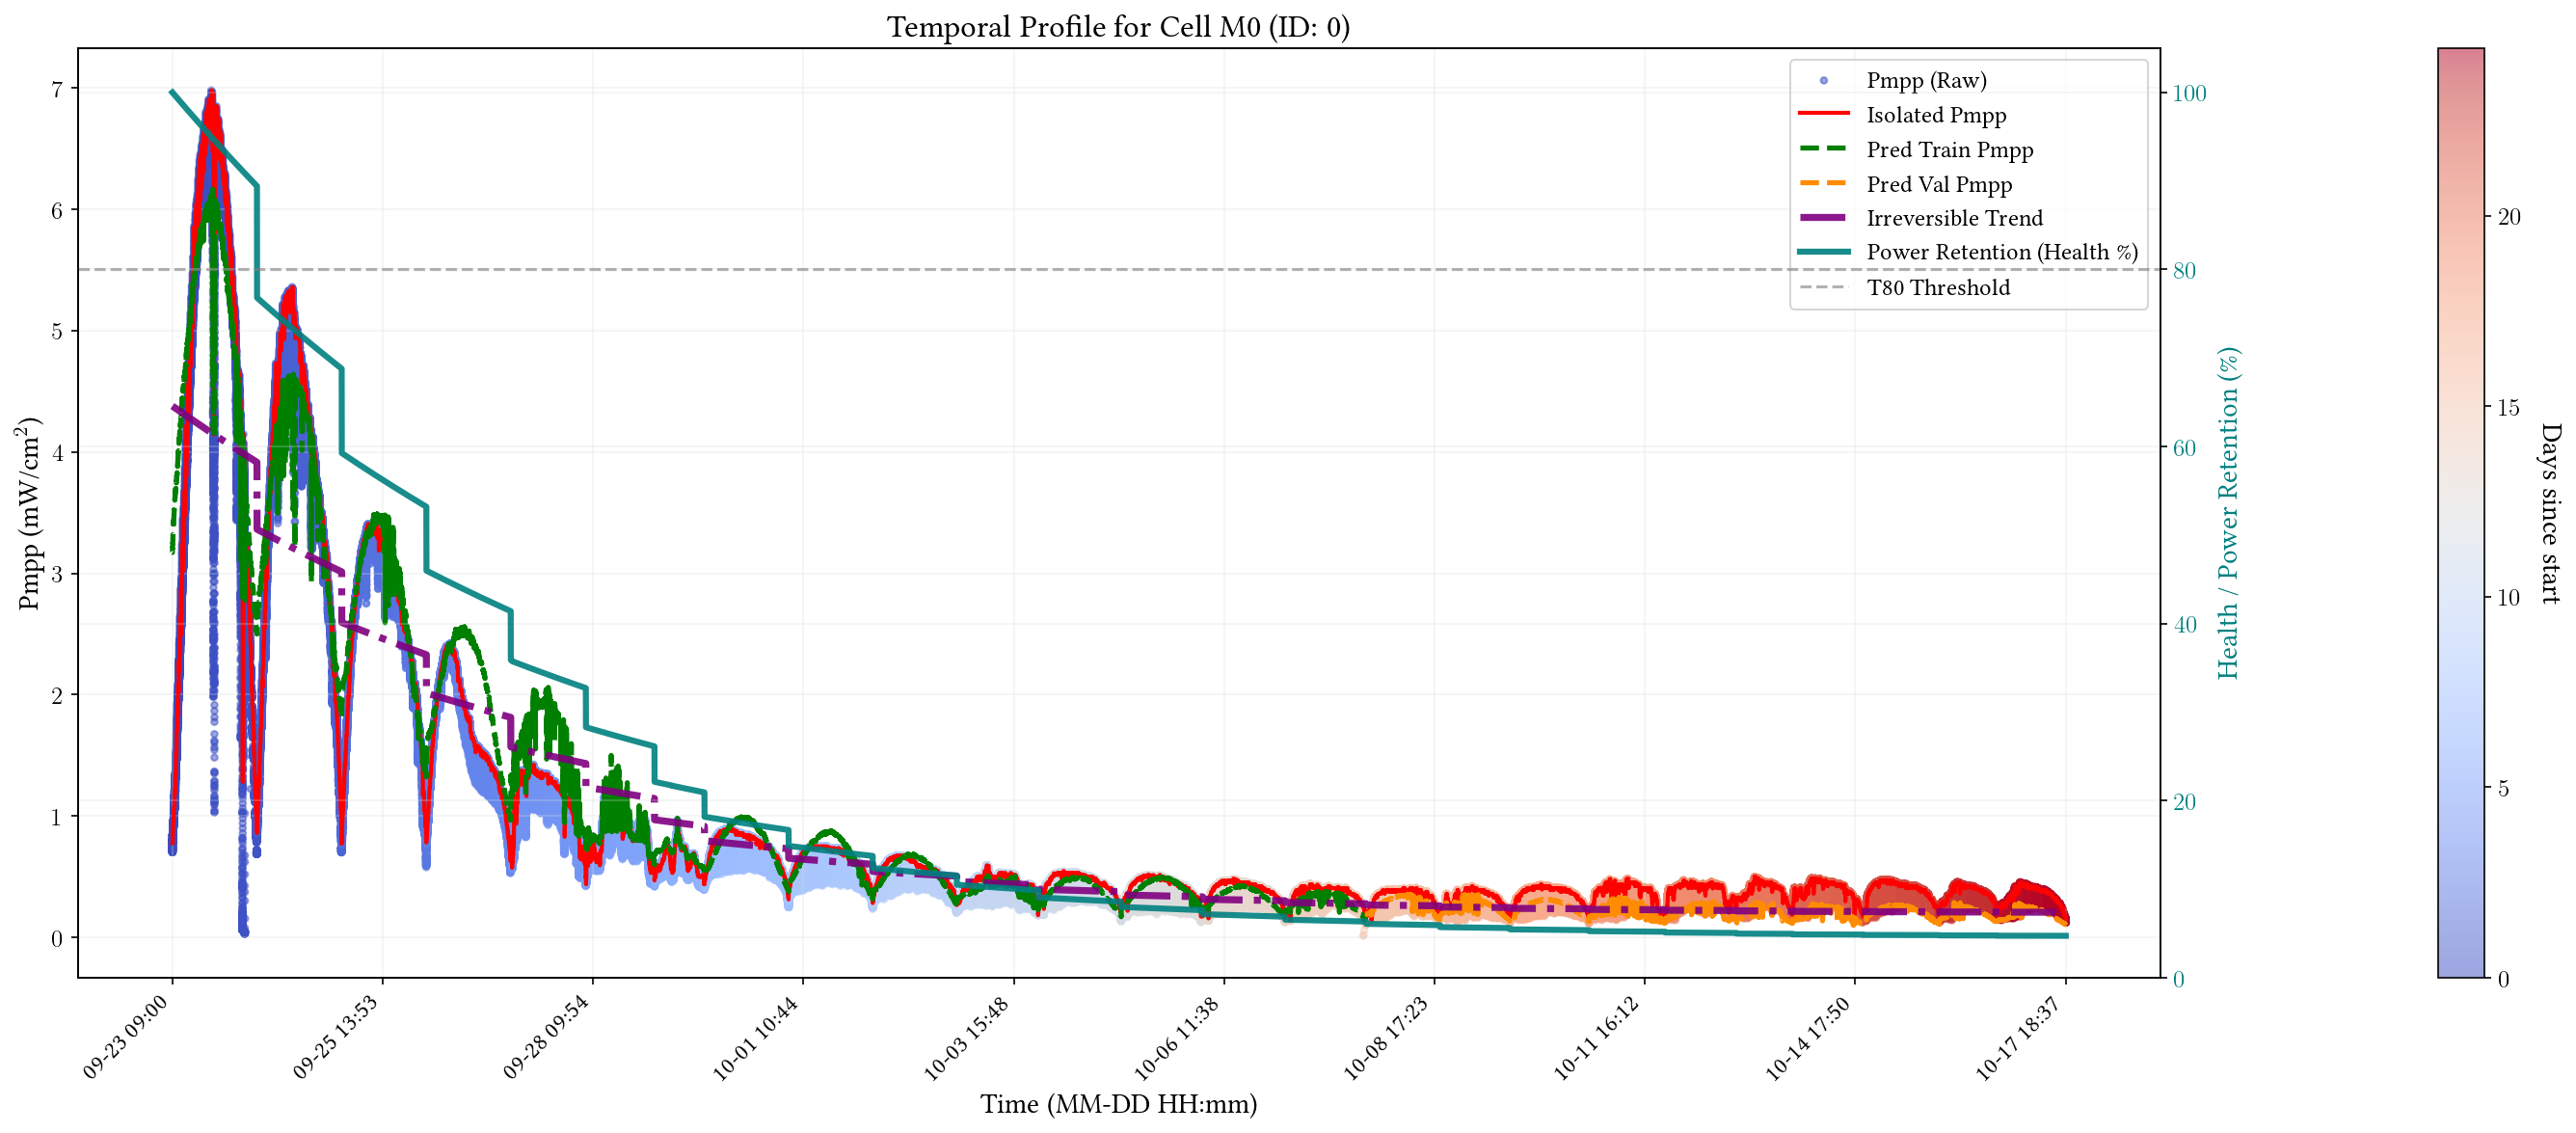


P12 Plot:


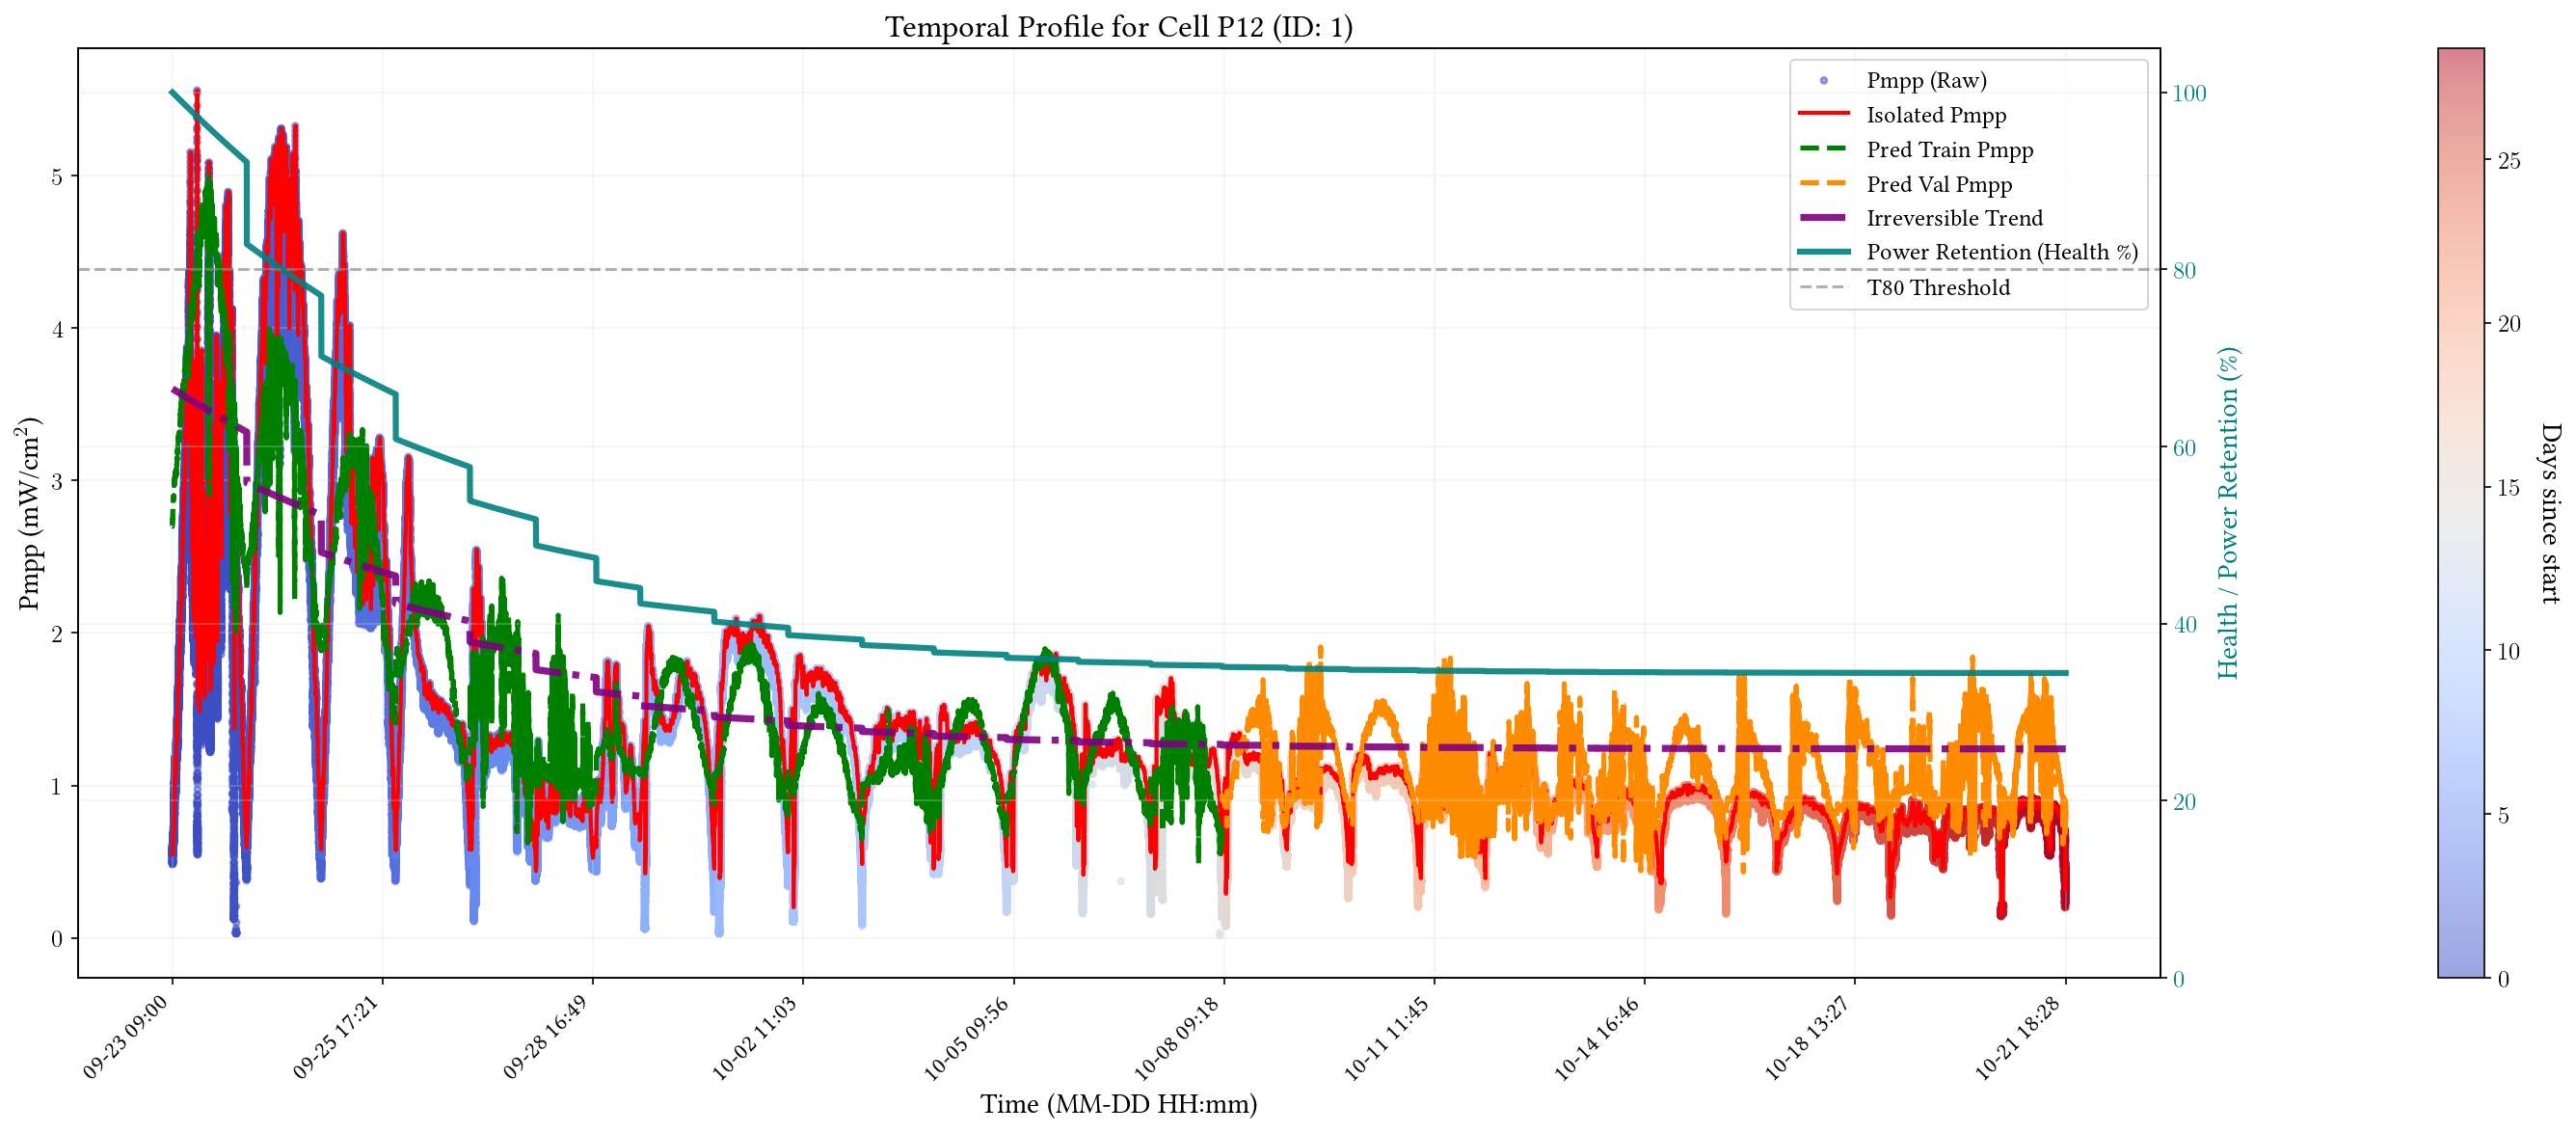

In [13]:
# --- VISUAL CHECK ---
print("M0 Plot:")
plot_profile(df=df_res_m0_lr, cell_id=0, min_gci=0, min_G_mwcm2=0, min_power=0, isolated_mpp_line=True,
             start_date=pd.to_datetime('2025-09-23'),
             end_date=pd.to_datetime('2025-09-23') + pd.Timedelta(days=25),
             color=True, temp=False, feature=None, predicted=True, trend=True, Health=True)

print("\nP12 Plot:")
plot_profile(df=df_res_p12_lr, cell_id=1, min_gci=0, min_G_mwcm2=0, min_power=0, isolated_mpp_line=True,
             start_date=pd.to_datetime('2025-09-23'),
             end_date=pd.to_datetime('2025-09-27') + pd.Timedelta(days=25),
             color=True, temp=False, feature=None, predicted=True, trend=True, Health=True)

In [14]:
plt.style.use('default')
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'text.latex.preamble': r'\usepackage{libertine} \usepackage[T1]{fontenc} \usepackage{amsmath} \usepackage{bm}',
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.color': '#E5E8E8',
    'grid.linestyle': '-',
    'figure.figsize': (4.5, 3.5)
})

latex_labels_map = {
    'G_mwcm2': r'$G$',
    'DeviceTemp': r'$T_{\text{c}}$',
    'HA_g_m3': r'$H_A$',
    'hour_sin': r'$\sin(2\pi h/24)$',
    'hour_cos': r'$\cos(2\pi h/24)$'
}

def analyze_and_plot_shap_mlr(model_pipeline, X_train, cell_name, output_filename):
    print(f"\n" + "="*55)
    print(f"--- SHAP AND PHYSICAL ANALYSIS: CELL {cell_name} (MLR) ---")
    print("="*55)

    # Extract the final linear model and transformed data (Z-score)
    model_final = model_pipeline[-1]
    X_train_transformed = model_pipeline[:-1].transform(X_train)

    # Configure the LINEAR explainer with the scaled data
    explainer = shap.LinearExplainer(model_final, X_train_transformed)
    shap_values = explainer.shap_values(X_train_transformed)

    # Original feature names
    feature_names = X_train.columns

    # --- 1. NUMERICAL ANALYSIS (CONSOLE) ---
    base_value = explainer.expected_value[0] if isinstance(explainer.expected_value, np.ndarray) else explainer.expected_value
    print(f"Base Value (Mean Prediction): {base_value:.4f} mW/cm²\n")

    # Global Importance = Mean Absolute Value (Feature strength)
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    # Physical Direction = Model Coefficient (Positive or negative impact)
    coeficientes = model_final.coef_

    # Create a DataFrame to show the analytical info
    df_shap = pd.DataFrame({
        'Feature': feature_names,
        'Global_Importance (|SHAP|)': mean_abs_shap,
        'Physical_Coefficient (Beta)': coeficientes
    }).sort_values(by='Global_Importance (|SHAP|)', ascending=False)

    print(df_shap.to_string(index=False, float_format="%.4f"))
    print("-" * 55)

    # --- 2. GRAPHIC EXPORT (PDF) ---
    # Map names to LaTeX for the plot
    feature_names_latex = [latex_labels_map.get(col, col) for col in feature_names]

    # Generate the summary_plot without showing it immediately (show=False)
    shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names_latex, plot_size=(5, 3), show=False)

    # Adjust labels and save using LaTeX format
    plt.xlabel(r'SHAP value (impact on $\hat{P}_{\text{stat}}$, mW/cm$^2$)')
    plt.savefig(output_filename, bbox_inches='tight', dpi=600)
    plt.close()

    print(f"Plot successfully saved as: {output_filename}")


# ==========================================
# EXECUTION FOR BOTH CELLS (MLR ONLY)
# ==========================================

# For M0
analyze_and_plot_shap_mlr(
    model_pipeline=model_lr_m0,
    X_train=X_train_m0,
    cell_name='M0',
    output_filename='shap_lr_m0.pdf'
)

# For P12
analyze_and_plot_shap_mlr(
    model_pipeline=model_lr_p12,
    X_train=X_train_p12,
    cell_name='P12',
    output_filename='shap_lr_p12.pdf'
)


--- SHAP AND PHYSICAL ANALYSIS: CELL M0 (MLR) ---
Base Value (Mean Prediction): 5.4603 mW/cm²

   Feature  Global_Importance (|SHAP|)  Physical_Coefficient (Beta)
   G_mwcm2                      1.0718                       1.2159
  hour_cos                      0.2739                      -0.3249
DeviceTemp                      0.2473                      -0.2997
  hour_sin                      0.1564                      -0.1775
   HA_g_m3                      0.1359                      -0.1739
-------------------------------------------------------
Plot successfully saved as: shap_lr_m0.pdf

--- SHAP AND PHYSICAL ANALYSIS: CELL P12 (MLR) ---
Base Value (Mean Prediction): 3.9195 mW/cm²

   Feature  Global_Importance (|SHAP|)  Physical_Coefficient (Beta)
   G_mwcm2                      1.0891                       1.2365
DeviceTemp                      0.6379                      -0.7712
  hour_sin                      0.1607                      -0.1823
   HA_g_m3                  